# CBIM Problem Canvas

### Situation
This dataset contains sales data from 12 retail stores in Andhra Pradesh. The stores sell products from five different categories, and the Category Manager has to review their performance before the supplier meeting.

### Complication
All categories and products are not performing in the same way. Some may be improving while others may be losing sales. Discounts are also being given, but we need to check whether they are actually helping sales.

### Question
Which categories and products are performing well, which ones need attention, and what should the Category Manager focus on during the supplier review?

### Single Source of Truth
The analysis is based on the `MUC01_Retail_Sales_Dataset.csv` file.

### Success Definition
At the end of the analysis, we should be able to clearly understand the sales trend, product performance, discount impact and sales patterns, and give a useful recommendation to the Category Manager.

### Primary Stakeholder
The main stakeholder is the Category Manager who will use these findings during the supplier review.

#  Understanding the Dataset

Before starting the actual analysis, I first checked the dataset to understand what type of data is available.

I looked at the number of rows and columns, data types, missing values, duplicate transactions and basic numerical information.

This helps to make sure that the data is ready before creating charts or drawing conclusions.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
sales = pd.read_csv("MUC01_Retail_Sales_Dataset.csv")

print("Dataset Shape:", sales.shape)
sales.head()

Dataset Shape: (107836, 10)


,transaction_id,date,store_id,store_city,category,product_name,units_sold,unit_price,revenue,discount_pct
0,TXN000001,2026-01-01,S01,Vijayawada,Electronics,Smart TV,2,3075.46,5843.37,5
1,TXN000002,2026-01-01,S01,Vijayawada,Electronics,Laptop,1,11598.06,11598.06,0
2,TXN000003,2026-01-01,S01,Vijayawada,Electronics,Tablet,3,5738.37,15493.60,10
3,TXN000004,2026-01-01,S01,Vijayawada,Electronics,Smart TV,3,3281.28,9351.65,5
4,TXN000005,2026-01-01,S01,Vijayawada,Apparel,Jeans,1,1917.14,1917.14,0


In [4]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 107836 entries, 0 to 107835
Data columns (total 10 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   transaction_id  107836 non-null  object 
 1   date            107836 non-null  object 
 2   store_id        107836 non-null  object 
 3   store_city      107836 non-null  object 
 4   category        107836 non-null  object 
 5   product_name    107836 non-null  object 
 6   units_sold      107836 non-null  int64  
 7   unit_price      107836 non-null  float64
 8   revenue         107836 non-null  float64
 9   discount_pct    107836 non-null  int64  
dtypes: float64(2), int64(2), object(6)
memory usage: 8.2+ MB


In [5]:
print("Missing Values:")
print(sales.isnull().sum())

print("\nDuplicate Transactions:")
print(sales["transaction_id"].duplicated().sum())

Missing Values:
transaction_id    0
date              0
store_id          0
store_city        0
category          0
product_name      0
units_sold        0
unit_price        0
revenue           0
discount_pct      0
dtype: int64

Duplicate Transactions:
0


In [6]:
sales[["units_sold", "unit_price", "revenue", "discount_pct"]].describe()

,units_sold,unit_price,revenue,discount_pct
count,107836.000000,107836.000000,107836.000000,107836.000000
mean,2.583488,1778.097787,4263.920924,7.228152
std,1.471616,5053.631792,14243.244169,6.730445
min,1.000000,50.020000,40.040000,0.000000
25%,1.000000,274.827500,467.772500,0.000000
50%,2.000000,488.450000,1034.615000,5.000000
75%,3.000000,1039.522500,2473.335000,10.000000
max,13.000000,44990.140000,355090.880000,20.000000


In [7]:
print("Total Categories:", sales["category"].nunique())
print("Total Products:", sales["product_name"].nunique())

print("\nCategories:")
print(sales["category"].unique())

Total Categories: 5
Total Products: 25

Categories:
['Electronics' 'Apparel' 'Grocery' 'Home & Kitchen' 'Personal Care']


### Initial Observations

The dataset contains a large number of sales transactions from different stores and product categories, so it is useful for comparing performance across the business.

There are five product categories with multiple products under each category.

I also checked the dataset for missing values and duplicate transaction IDs. Since there are no major data quality issues, the dataset can be used directly for further analysis.


 Category Revenue Trend

In this section, I checked how the revenue of each category changed from month to month.

This is useful because only looking at total revenue may not show whether a category is improving or declining over time.

The main aim here is to find the category with the strongest growth, the biggest decline and the most stable performance.


In [8]:
sales["date"] = pd.to_datetime(sales["date"])
sales["month"] = sales["date"].dt.to_period("M")

monthly_sales = (
    sales.groupby(["month", "category"])["revenue"]
    .sum()
    .reset_index()
)

monthly_sales["month"] = monthly_sales["month"].astype(str)

monthly_sales.head()

,month,category,revenue
0,2026-01,Apparel,10049916.78
1,2026-01,Electronics,45686596.63
2,2026-01,Grocery,7307011.34
3,2026-01,Home & Kitchen,15130871.54
4,2026-01,Personal Care,6593734.81


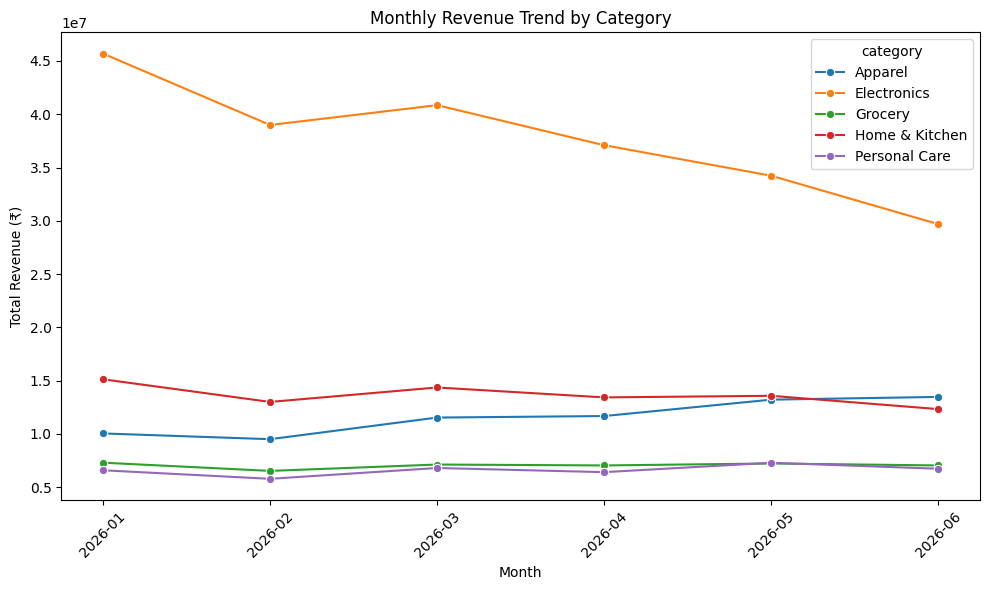

In [9]:
plt.figure(figsize=(10, 6))

sns.lineplot(
    data=monthly_sales,
    x="month",
    y="revenue",
    hue="category",
    marker="o"
)

plt.title("Monthly Revenue Trend by Category")
plt.xlabel("Month")
plt.ylabel("Total Revenue (₹)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [10]:
revenue_table = monthly_sales.pivot(
    index="month",
    columns="category",
    values="revenue"
)

change = pd.DataFrame({
    "First Month Revenue": revenue_table.iloc[0],
    "Last Month Revenue": revenue_table.iloc[-1]
})

change["Percentage Change"] = (
    (change["Last Month Revenue"] - change["First Month Revenue"])
    / change["First Month Revenue"]
) * 100

change.round(2)

,First Month Revenue,Last Month Revenue,Percentage Change
category,,,
Apparel,10049916.78,13476952.88,34.10
Electronics,45686596.63,29686824.81,-35.02
Grocery,7307011.34,7047719.23,-3.55
Home & Kitchen,15130871.54,12333283.07,-18.49
Personal Care,6593734.81,6737354.12,2.18


### Observation

From the monthly revenue chart, it is clear that all categories are not following the same trend.

One category shows a noticeable fall in revenue over the six-month period, while another category remains comparatively stable. A growing category also shows better performance towards the later months.

For the supplier review, the declining category should be discussed carefully because its recent performance may not support additional shelf space or promotional investment. At the same time, categories showing steady or improving revenue can be considered for more support.


Electronics shows the strongest decline, while Grocery is relatively stable.

#  Top and Bottom Products

After checking category-level performance, I analysed individual products.

The purpose of this step is to find the top two and bottom two products based on total revenue inside each category.

This gives a better idea of which products are helping the category and which products may need attention.

In [12]:
product_revenue = (
    sales.groupby(["category", "product_name"])["revenue"]
    .sum()
    .reset_index()
)

top_products = (
    product_revenue
    .sort_values(["category", "revenue"], ascending=[True, False])
    .groupby("category")
    .head(2)
)

bottom_products = (
    product_revenue
    .sort_values(["category", "revenue"], ascending=[True, True])
    .groupby("category")
    .head(2)
)

In [13]:
print("Top 2 Products in Each Category")
display(top_products)

print("Bottom 2 Products in Each Category")
display(bottom_products)

Top 2 Products in Each Category


,category,product_name,revenue
3,Apparel,Saree,14161864.63
4,Apparel,T-Shirt,14099251.65
5,Electronics,Headphones,47696053.99
6,Electronics,Laptop,46551078.39
13,Grocery,Rice (5kg),8562171.86
11,Grocery,Dal (1kg),8488303.64
16,Home & Kitchen,Mixer Grinder,16903254.58
18,Home & Kitchen,Storage Box,16676535.31
22,Personal Care,Shampoo,8168328.26
20,Personal Care,Body Lotion,8106578.00


Bottom 2 Products in Each Category


,category,product_name,revenue
2,Apparel,Kurta,13606747.03
0,Apparel,Formal Shirt,13748976.91
8,Electronics,Smart TV,41882166.21
9,Electronics,Tablet,44744388.93
14,Grocery,Sugar (1kg),8377786.05
12,Grocery,Oil (1L),8431630.01
19,Home & Kitchen,Water Bottle,15825842.17
17,Home & Kitchen,Pressure Cooker,16142329.39
23,Personal Care,Sunscreen,7593863.45
24,Personal Care,Toothpaste,7768812.48


### Product Performance Observation

The results show that there is a clear difference between the strongest and weakest products within each category.

The bottom-performing products should not be ignored because they may be one of the reasons for weak category performance.

For the supplier review, I would first focus on the category that is already showing a declining revenue trend and then check whether its low-performing products are contributing to that decline.

Instead of treating the whole category in the same way, the Category Manager can separately review the stronger and weaker products.


# Discount Effectiveness

Discounts are usually given to increase customer purchases, but a higher discount does not always mean better sales.

In this section, I grouped the transactions based on discount percentage and compared the average revenue and average units sold.

This helps to check whether customers are actually buying more when higher discounts are offered.

In [14]:
bins = [-1, 0, 5, 10, 15, 20, 100]
labels = ["0%", "5%", "10%", "15%", "20%", "25%+"]

sales["discount_group"] = pd.cut(
    sales["discount_pct"],
    bins=bins,
    labels=labels
)

discount_analysis = (
    sales.groupby("discount_group", observed=False)
    .agg(
        Average_Revenue=("revenue", "mean"),
        Average_Units=("units_sold", "mean")
    )
    .reset_index()
)

discount_analysis.round(2)

,discount_group,Average_Revenue,Average_Units
0,0%,4685.65,2.59
1,5%,4303.73,2.59
2,10%,4005.55,2.57
3,15%,4069.16,2.60
4,20%,3631.73,2.58
5,25%+,NaN,NaN


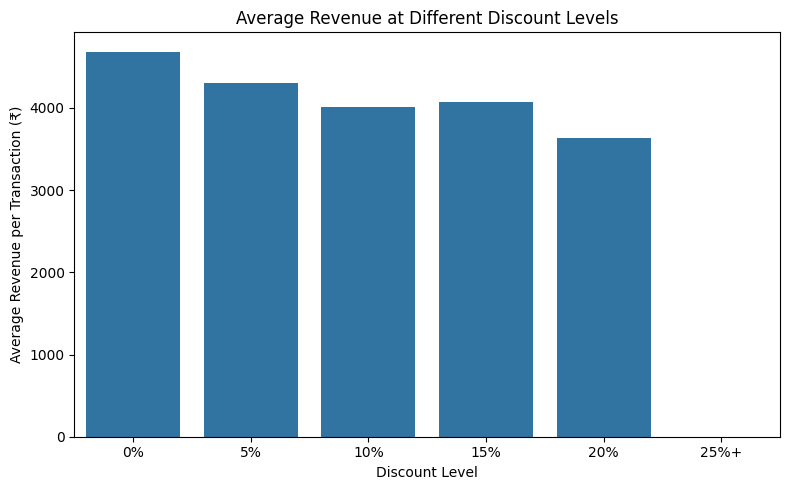

In [15]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=discount_analysis,
    x="discount_group",
    y="Average_Revenue"
)

plt.title("Average Revenue at Different Discount Levels")
plt.xlabel("Discount Level")
plt.ylabel("Average Revenue per Transaction (₹)")
plt.tight_layout()
plt.show()

# Business Insight

Higher discounts do not show a proportionate revenue benefit in this dataset. Average revenue per transaction falls from ₹4,686 at 0% discount to ₹3,632 at 20% discount, which is about a 22.5% decrease.

At the same time, average units sold remain almost unchanged at around 2.6 units per transaction. This means higher discounts are not leading to a meaningful increase in units sold.

Based on these results, higher discounts should be used carefully and reviewed before increasing them further. The 25%+ bracket has no transactions in this dataset.

# Day of Week and Monthly Patterns

I will look at sales by day of the week and by month to understand when the chain and Electronics category perform better or worse. This can help identify suitable timings for promotions.

In [17]:
sales["day"] = sales["date"].dt.day_name()

daily_revenue = sales.groupby(
    ["date", "day"]
)["revenue"].sum().reset_index()

day_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

day_revenue = daily_revenue.groupby(
    "day"
)["revenue"].mean().reindex(day_order)

day_revenue

day
Monday       2.012141e+06
Tuesday      2.054130e+06
Wednesday    2.228117e+06
Thursday     2.245493e+06
Friday       2.623612e+06
Saturday     3.523605e+06
Sunday       3.083375e+06
Name: revenue, dtype: float64

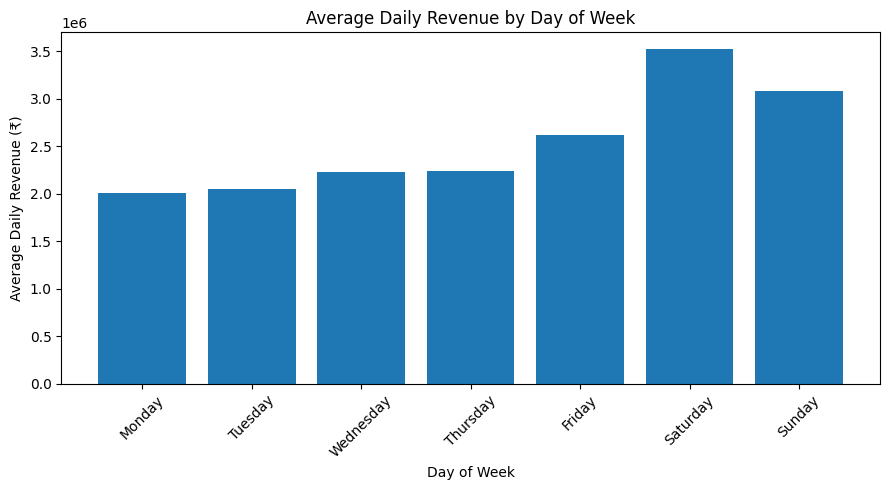

In [18]:
plt.figure(figsize=(9, 5))
plt.bar(day_revenue.index, day_revenue.values)
plt.title("Average Daily Revenue by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Daily Revenue (₹)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [19]:
best_day = day_revenue.idxmax()
worst_day = day_revenue.idxmin()

print("Best day:", best_day)
print("Worst day:", worst_day)

Best day: Saturday
Worst day: Monday


In [21]:
monthly_chain = sales.groupby("month")["revenue"].sum()
monthly_chain

month
2026-01    84768131.10
2026-02    73833666.23
2026-03    80689884.84
2026-04    75670487.12
2026-05    75559873.38
2026-06    69282134.11
Freq: M, Name: revenue, dtype: float64

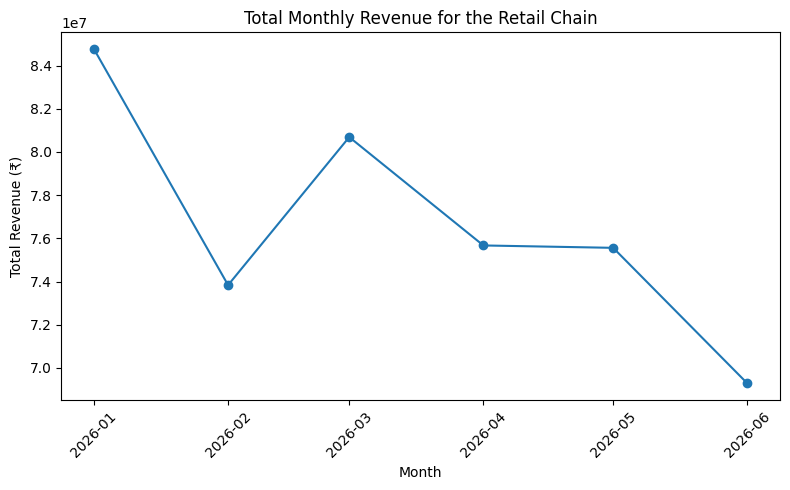

In [24]:
plt.figure(figsize=(8, 5))

plt.plot(
    monthly_chain.index.to_timestamp(),
    monthly_chain.values,
    marker="o"
)

plt.title("Total Monthly Revenue for the Retail Chain")
plt.xlabel("Month")
plt.ylabel("Total Revenue (₹)")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [25]:
best_month = monthly_chain.idxmax()
worst_month = monthly_chain.idxmin()
print("Best month:", best_month)
print("Worst month:", worst_month)

Best month: 2026-01
Worst month: 2026-06


In [27]:
electronics = sales[sales["category"] == "Electronics"]
electronics_daily = electronics.groupby(
    ["date", "day"]
)["revenue"].sum().reset_index()
electronics_day_revenue = electronics_daily.groupby(
    "day"
)["revenue"].mean().reindex(day_order)
electronics_day_revenue

day
Monday       9.709755e+05
Tuesday      9.754327e+05
Wednesday    1.111579e+06
Thursday     1.061518e+06
Friday       1.291064e+06
Saturday     1.786658e+06
Sunday       1.558130e+06
Name: revenue, dtype: float64

In [28]:
electronics_monthly = electronics.groupby("month")["revenue"].sum()
electronics_monthly

month
2026-01    45686596.63
2026-02    38988602.50
2026-03    40846509.47
2026-04    37092265.09
2026-05    34226926.43
2026-06    29686824.81
Freq: M, Name: revenue, dtype: float64

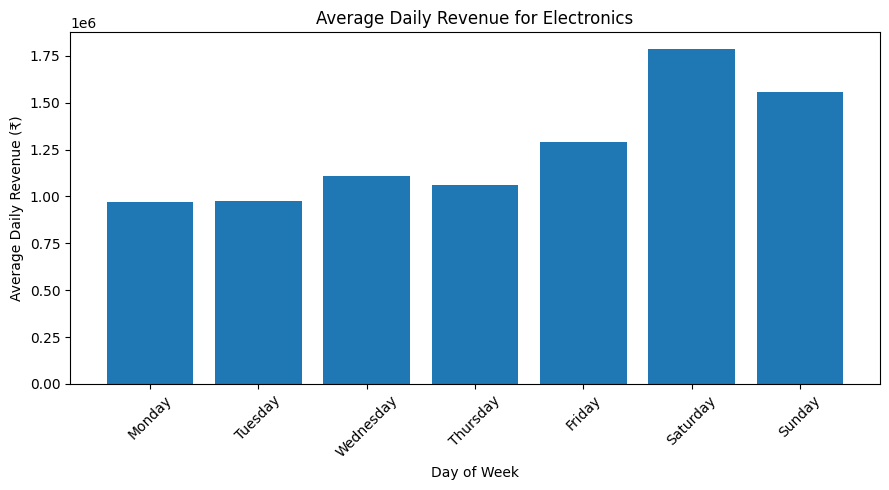

In [29]:
plt.figure(figsize=(9, 5))
plt.bar(
    electronics_day_revenue.index,
    electronics_day_revenue.values
)
plt.title("Average Daily Revenue for Electronics")
plt.xlabel("Day of Week")
plt.ylabel("Average Daily Revenue (₹)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

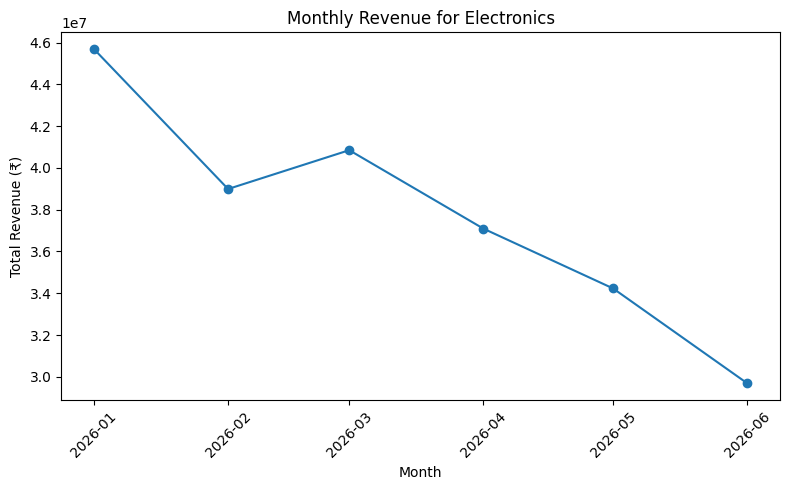

In [31]:
plt.figure(figsize=(8, 5))

plt.plot(
    electronics_monthly.index.to_timestamp(),
    electronics_monthly.values,
    marker="o"
)

plt.title("Monthly Revenue for Electronics")
plt.xlabel("Month")
plt.ylabel("Total Revenue (₹)")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [32]:
print("Electronics best day:", electronics_day_revenue.idxmax())
print("Electronics worst day:", electronics_day_revenue.idxmin())

print("Electronics best month:", electronics_monthly.idxmax())
print("Electronics worst month:", electronics_monthly.idxmin())

Electronics best day: Saturday
Electronics worst day: Monday
Electronics best month: 2026-01
Electronics worst month: 2026-06


# Business Insight

For the overall retail chain, Saturday has the highest average daily revenue, at around ₹35.24 lakh, while Monday has the lowest at around ₹20.12 lakh. January is the best-performing month, with revenue of about ₹8.48 crore, whereas June has the lowest revenue at around ₹6.93 crore.

Electronics also follows a similar pattern, with Saturday performing the best and Monday the lowest. January is the strongest month for Electronics, while June is the weakest.

This shows that sales are generally higher on weekends, especially Saturdays. So, Electronics promotions can be focused more on Saturdays and other high demand periods, while less focus may be needed on Mondays.


Apparel has the strongest case for increased investment because its revenue grew by about 34.1% from January to June. Electronics needs attention because its revenue fell by about 35.0%, and Smart TV was the lowest-revenue Electronics product at about ₹4.19 crore over the six months. I would challenge the Electronics category supplier on the performance of Smart TV and Tablet and ask for a clear plan for improving the weaker products. Higher discounts do not show a proportionate revenue benefit, with average revenue per transaction falling from ₹4,686 at 0% discount to ₹3,632 at 20% discount while average units sold stayed around 2.6. Before making a final supplier decision, I would want supplier level performance data to connect the weaker products to specific suppliers.